# Convective-Diffusive Equation

The convective-diffusive equation is a partial diferential equation (PDE) commonly written as

$$
\partial_t u + \partial_{\alpha}B_{\alpha} - \partial_{\alpha}\left(\nu \partial_{\alpha} C \right)  = 0
$$(cvdif-eq-lb)

where $u(\alpha,t)$ is a space and time dependent scalar parameter, $B_{\alpha}(\alpha,t)$ is a vector a $C$ a scalar term, may be time and space dependent parameters and can also be also expressed as linear or non-linear functions of $u(\alpha,t)$. The term $\nu$ is the diffusion coefficient, a constituve term that controls the intensity of diffusive effect.

## Numerical Discretization

Discretizing the above equation in regular grid of 1D domain, we have

```{figure} mesh-1-convective-diffusive.*
---
scale: 250%
align: center
name: mesh-1-convective-diffusive
---
1D regular grid.
```

### FDM Discretization

To explore different discretization approaches, we adopt forward-time, forward-space (commonly referred to as the upwind scheme), as well as central-difference schemes.

#### Forward-Time and Forward-Space (FTFSCS)
Discretizing the Eq. {eq}`cvdif-eq-lb` through finite diference method, we have for forward-time, forward-space for advection and central-space for diffusion (FTFSCS) discretizations:

::::{only} html
$$
\partial_t u + \partial_{\alpha}B_{\alpha} - \partial_{\alpha}\left(\nu \partial_{\alpha} C \right) = \frac{u(x,t + \Delta_{t}) - u(x,t) }{\Delta_{t}} + \frac{B_{\alpha}(x,t) - B_{\alpha}(x + \Delta_{x},t) }{\Delta_{x}} - \nu\frac{ C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) }{\Delta_{x}^{2}} =0,
$$
::::

::::{only} latex
$$
\begin{array}{ll}
\partial_t u + \partial_{\alpha}B_{\alpha} - \partial_{\alpha}\left(\nu \partial_{\alpha} C \right) = & \displaystyle\frac{u(x,t + \Delta_{t}) - u(x,t) }{\Delta_{t}} + \frac{B_{\alpha}(x,t) - B_{\alpha}(x + \Delta_{x},t) }{\Delta_{x}} \\
& - \nu \displaystyle\frac{ C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) }{\Delta_{x}^{2}} =0,
\end{array}
$$
::::

isolating the term $u(x,t + \Delta_{t})$, we can describe the $u$ time evolution:

$$
u(x,t + \Delta_{t})   = u(x,t) - \frac{\Delta_{t}}{\Delta_{x}} \left( B_{\alpha}(x,t) - B_{\alpha}(x + \Delta_{x},t) \right) + \frac{\nu\Delta_{t}}{\Delta_{x}^{2}} \left( C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) \right) 
$$

#### Forward-Time and Central-Space with Small Diffusivity (FTCS)

Given the discretization of the convective-diffusive equation with pure forwar-time and central-space in advective and diffusive terms (FTCS), we have

::::{only} html
$$
\partial_t u + \partial_{x}B_{\alpha} - \partial_{\alpha}\left( \nu \partial_{\alpha}u \right) = \frac{u(x,t + \Delta_{t}) - u(x,t) }{\Delta_{t}} + \frac{B_{\alpha}(x+\Delta_{x},t) - B_{\alpha}(x - \Delta_{x},t) }{2\Delta_{x}} - \nu\frac{ C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) }{\Delta_{x}^{2}} =0,
$$
::::

::::{only} latex
$$
\begin{array}{ll}
\partial_t u + \partial_{x}B_{\alpha} - \partial_{\alpha}\left( \nu \partial_{\alpha}u \right) =& \displaystyle\frac{u(x,t + \Delta_{t}) - u(x,t) }{\Delta_{t}} + \frac{B_{\alpha}(x+\Delta_{x},t) - B_{\alpha}(x - \Delta_{x},t) }{2\Delta_{x}} \\
& - \nu \displaystyle\frac{ C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) }{\Delta_{x}^{2}} =0,
\end{array}
$$
::::

isolating the term $u(x,t + \Delta_{t})$, we can describe the $u$ time evolution:

$$
u(x,t + \Delta_{t})   = u(x,t) - \frac{\Delta_{t}}{2\Delta_{x}} \left( B_{\alpha}(x+\Delta_{x},t) - B_{\alpha}(x - \Delta_{x},t) \right) + \frac{\nu\Delta_{t}}{\Delta_{x}^{2}} \left( C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) \right) 
$$

#### Forward-Time and Central-Space with Small Diffusivity (FTCS-SD)

Give that discretize convective equation with pure forwar-time and central-space (FTCS), employ a small diffusivity (FTCS-SD) is a alternative to improve stability and ensure a propertie conservation.

$$
\begin{array}{c}
\partial_t u + \partial_{x}B_{\alpha} - \partial_{\alpha}\left( \nu_{u} \partial_{\alpha}u \right) - \partial_{\alpha}\left( \nu \partial_{\alpha}C \right) = \displaystyle\frac{u(x,t + \Delta_{t}) - u(x,t) }{\Delta_{t}} + \frac{B_{\alpha}(x+\Delta_{x},t) - B_{\alpha}(x - \Delta_{x},t) }{\Delta_{x}} -\\
\nu_{u} \displaystyle\frac{ u(x - \Delta_{x},t) -2u(x,t) + u(x + \Delta_{x},t) }{\Delta_{x}^{2}} - \nu\frac{ C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) }{\Delta_{x}^{2}} =0,
\end{array}
$$

isolating the term $u(x,t + \Delta_{t})$, we can describe the $u$ time evolution:

::::{only} html
$$
u(x,t + \Delta_{t})   = u(x,t) - \frac{\Delta_{t}}{\Delta_{x}} \left( B_{\alpha}(x+\Delta_{x},t) - B_{\alpha}(x - \Delta_{x},t) \right) + \frac{\nu_{u}\Delta_{t}}{\Delta_{x}^{2}} \left( u(x - \Delta_{x},t) -2u(x,t) + u(x + \Delta_{x},t) \right) + \frac{\nu\Delta_{t}}{\Delta_{x}^{2}} \left( C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) \right) .
$$
::::

::::{only} latex
$$
\begin{array}{ll}
u(x,t + \Delta_{t})   =& u(x,t) - \displaystyle\frac{\Delta_{t}}{\Delta_{x}} \left( B_{\alpha}(x+\Delta_{x},t) - B_{\alpha}(x - \Delta_{x},t) \right) + \frac{\nu_{u}\Delta_{t}}{\Delta_{x}^{2}} \left( u(x - \Delta_{x},t) -2u(x,t) + u(x + \Delta_{x},t) \right) \\ 
& + \displaystyle\frac{\nu\Delta_{t}}{\Delta_{x}^{2}} \left( C(x - \Delta_{x},t) -2C(x,t) + C(x + \Delta_{x},t) \right) .
\end{array}
$$
::::

### Lattice Boltzmann Equation

Describing the problem through the BGK lattice Boltzmann equation:

$$
f_{i}\left(x_{\alpha}+ c_{i,\alpha} \Delta t, t+\Delta t\right)- f_{i}(x_{\alpha}, t)= -\left( \frac{ f_{i} - f_{i}^{eq} }{ \tau } \right).
$$(LB-cvdif-Eq)

The equilibrium distribution function is defined by

$$
f^{eq}_{i} = w_{i}\left( u + \frac{c_{i,\alpha} B_{\alpha}}{c_{s}^{2}} + \frac{ \left( c_{s}^{2}C\delta_{\alpha\beta} + \Lambda_{\alpha\beta} - c_{s}^{2}u\delta_{\alpha\beta} \right) \left( c_{i,\alpha}c_{i,\beta} - c_{s}^{2}\delta_{\alpha\beta} \right)}{2c_{s}^{4}}  \right),
$$

where $\Lambda_{\alpha\beta}$ is a correction term defined by

$$
\Lambda_{\alpha\beta} = \displaystyle\int  B_{\alpha}^{'}B_{\beta}^{'}  du = \displaystyle\int \left(\displaystyle\frac{\partial B_{\alpha}}{\partial u} \displaystyle\frac{\partial B_{\beta}}{\partial u} \right) du.
$$

#### Lattice Direction Moments

In [30]:
import warnings
warnings.filterwarnings("ignore")
from pylab import *
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
from IPython.display import display, Math, Latex
#-------------------------------------------------Símbolos----------------------------------------------
omega, u, B, w, C, Lamb = symbols('omega, u, B_{\\alpha}, w, C, \\Lambda_{\\alpha\\beta}')
wi, cx, cy, cs = symbols('w_{i} c_{x} c_{y} c_{s}')
fi, f0, f1, f2  = symbols('f_{i} f_{0} f_{1} f_{2}')
#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
fneq = Function('fneq')(wi, cx, cy)
f = Function('f')(fi)
#----------------------------------------------Lattice-D2Q9---Variáveis----------------------------------------------
fi=np.array([f0,f1,f2])
w0=Rational(4,6);w1=Rational(1,6)
wi=np.array([w0,w1,w1])
cx=np.array([0,1,-1])
as2=Rational(3)
cs2=1/as2
#-------------------------------------------------Calc.Func------------------------------------------------
f= fi
feq=wi*(u + cx*B/cs2 + ((C*cs2 + Lamb -u*cs2)*(cx*cx-cs2))/(2*cs2**2))

##### Raw Moments

In [26]:
a0=simplify(sum(feq))
ax=simplify(sum(feq*cx))
axx=simplify(sum(feq*cx*cx))
axxx=simplify(sum(feq*cx*cx*cx))
display(Math(r"\begin{gathered}"
             r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Moment}} =" +  sp.latex(a0) 
            +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,x} }_{\textrm{x-First-Order Moment}} =" +  sp.latex(ax)
            +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x} }_{\textrm{xx-Second-Order Moment}} =" +  sp.latex(axx)
            +r",\quad \underbrace{\sum_{i=0} f_{i}^{eq} c_{i,x}c_{i,x}c_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" +  sp.latex(axxx) 
            +r".\end{gathered}"
            ))

<IPython.core.display.Math object>

##### Hermite Moments

In [25]:
aH0=simplify(sum(feq))
aHx=simplify(sum(feq*cx))
aHxx=simplify(sum(feq*(cx*cx-cs2)))
aHxxx=simplify(sum(feq*(cx*cx-3*cs2)*cx))
display(Math(r"\begin{gathered}"
             r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Hermite Moment}} =" +  sp.latex(aH0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}c_{i,x} }_{\textrm{x-First-Order Hermite Moment}} =" +  sp.latex(aHx) 
            +r",\end{gathered}"
            ))
display(Math(r"\begin{gathered}"
            +r"\underbrace{\sum_{i=0} f_{i}^{eq} \left(c_{i,x}c_{i,x} - c_{s}^{2} \right) }_{\textrm{xx-Second-Order Hermite Moment}} =" +  sp.latex(aHxx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(c_{i,x}c_{i,x} - 3c_{s}^{2} \right) c_{i,x} }_{\textrm{xxx-Third-Order Hermite Moment}} =" +  sp.latex(aHxxx) 
            +r".\end{gathered}"
            ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Chapmann-Enskog Analysis

<!-- ```{toggle} -->
Applying the Chapmann-Enskog procedure to LB equation, we expand the term $f_{i}\left(\boldsymbol{x}+\boldsymbol{e}_i \Delta t, t+\Delta t\right)$ in a Taylor series to recover the derivative form of the equation, i.e.,

$$
f_{i}\left( x_{\alpha} + c_{i,\alpha} \Delta t, t+\Delta t\right)- f_{i}(x_{\alpha}, t)=\displaystyle\sum_{j=1}^{\infty}\frac{\Delta t^{j}}{j!}D_{t}^{j}f_{i}= -\left( \frac{ f_{i} - f_{i}^{eq} }{ \tau } \right) .
$$(EqExp-cvdif-NotEq)

Rescaling the dimensionless form of the Eq. {eq}`EqExp-cvdif-NotEq` in terms of the Knudsen number ($Kn$), we have

$$
\displaystyle \sum^{\infty}_{j=1}  \frac{Kn^{(j-1)}}{j!} D_{t}^{j} f_{i} = - \frac{1}{Kn}\left( \frac{ f_{i} - f_{eq,i} }{ \tau } \right) \quad \quad \rightarrow \quad \quad \displaystyle \sum^{\infty}_{j=1}  \frac{Kn^{(j)}}{j!} D_{t}^{j} f_{i} = -  \frac{ f_{i} - f_{i}^{eq} }{ \tau },
$$

applying the asymptotic expansion in both the distribution function ($f_{i}=f_{i}^{(0)}+Kn f_{i}^{(1)} + Kn^{2} f_{i}^{(2)}+\cdots$) and time partial derivative ($\partial_{t}=\partial_{t}^{(0)}+ Kn \partial_{t}^{(1)}+Kn^{2} \partial_{t}^{(2)}+\cdots$), and separating the equation in orders up to the order $Kn^{2}$:

$$
\begin{array}{ll}
    (Kn^{(0)}):& f_{i}^{(0)}= f_{i}^{eq},\\
    (Kn^{(1)}):& \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)}= - \displaystyle\frac{ f_{i}^{(1)} }{ \tau } , \\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(1)} + \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(0)}}{2}= - \displaystyle\frac{ f_{i}^{(2)} }{ \tau },\\
    \textrm{ou}& \\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)\displaystyle\left(1 - \frac{1}{2\tau}\right) f_{i}^{(1)} =  - \displaystyle\frac{ f_{i}^{(2)} }{ \tau } \quad\quad \rightarrow \quad\quad  f_{i}^{(1)}\textrm{ Formulation} \\
    \textrm{ou}& \\
    (Kn^{(2)}):& \partial_{t}^{(1)} f_{i}^{(0)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} \displaystyle\left(\frac{1}{2} - \tau\right) f_{i}^{(0)} =  - \displaystyle\frac{ f_{i}^{(2)} }{ \tau } \quad\quad \rightarrow  \quad\quad f_{i}^{(0)}\textrm{ Formulation} \\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} +\partial_{t}^{(1)} f_{i}^{(1)} + \partial_{t}^{(1)}\left( \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)} \right) + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(2)} + \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)}}{2} \\
    & +  \displaystyle\frac{\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{3} f_{i}^{(0)}}{6} = - \displaystyle\frac{ f_{i}^{(3)} }{ \tau },  \\
    \textrm{ou}& \\
    (Kn^{(3)}):& \partial_{t}^{(2)} f_{i}^{(0)} + \left(1-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(\frac{1}{2} - \frac{1}{6\tau}\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(2)} =  - \displaystyle\frac{f_{i}^{(3)}}{\tau},
 \end{array}
$$(Chap-Kn-cvdif-NotEq)

**Zero-Order Moment Balance**

To retrieve the balance equation, we sum the Eq. {eq}`Chap-Kn-cvdif-NotEq` for $Kn^{(1)}$ and $Kn^{(2)}$ over $\sum_{i=0} $:

$$
\begin{array}{l}
(Kn^{(1)}): \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(0)}= - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } \right),\\
(Kn^{(1)}): \partial_{t}^{(0)}  u + \partial_{\alpha} B_{\alpha} =0,
\end{array}
$$(cvdif-Kn1-B0-all)

$$
\begin{array}{ll}
(Kn^{(2)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(1)} f_{i}^{(0)} + \displaystyle\left(1 - \frac{1}{2\tau}\right)\left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right) f_{i}^{(1)}   \right]=  - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(2)} }{ \tau } \right), \nonumber \\
(Kn^{(2)}):& \partial_{t}^{(1)} u + \displaystyle\left(1 - \frac{1}{2\tau}\right)\partial_{\alpha} m^{(1)}_{\alpha} = 0,
\end{array}
$$(cvdif-Kn2-B0-all)

To determine the unknow term $m^{(1)}_{\alpha}$, we sum the Eq. {eq}`Chap-Kn-cvdif-NotEq` for $Kn^{(1)}$ over the first-order moment:

$$
\begin{array}{l}
(Kn^{(1)}): \displaystyle\sum_{i}\left( \partial_{t}^{(0)} + c_{i,\beta}\partial_{\beta} \right)f_{i}^{(0)}c_{i,\alpha}= - \displaystyle\sum_{i}\left(\displaystyle\frac{ f_{i}^{(1)} }{ \tau } c_{i,\alpha} \right),\\
(Kn^{(1)}): \partial_{t}^{(0)}  B_{\alpha} + \partial_{\beta} \left(c_{s}^{2} C \delta_{\alpha\beta} + \Lambda_{\alpha\beta}\right) = - \displaystyle\frac{m^{(1)}_{\alpha}}{\tau} \quad \quad \rightarrow \quad \quad   m^{(1)}_{\alpha} =-\tau \partial_{\beta} \left(c_{s}^{2} C \delta_{\alpha\beta} \right).
\end{array}
$$(cvdif-Kn1-B1-all)


Extending the analysis up to $Kn^{(3)}$

::::{only} html
$$
\begin{array}{ll}
(Kn^{(3)}):& \displaystyle\sum_{i}\left[ \partial_{t}^{(2)} f_{i}^{(0)} + \left(1-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(\frac{1}{2} - \frac{1}{6\tau}\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(2)} \right] =  - \displaystyle\sum_{i}\left[\displaystyle\frac{f_{i}^{(3)}}{\tau} \right], \\
(Kn^{(3)}):& \partial_{t}^{(2)} u + \partial_{t}^{(1)}\left(\partial_{\alpha} m^{(1)}_{\alpha} + \partial_{\beta} m^{(1)}_{\beta}\right) + \partial_{\alpha}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{\alpha} m^{(2)}_{\alpha} = 0.
\end{array}
$$(cvdif-Kn3-B0-all)
::::

::::{only} latex
$$
\begin{array}{ll}
(Kn^{(3)}):& \displaystyle\sum_{i}\Bigg[ \partial_{t}^{(2)} f_{i}^{(0)} + \left(1-\displaystyle\frac{1}{\tau}\right)\partial_{t}^{(1)} f_{i}^{(1)} + \displaystyle\left(\frac{1}{2} - \frac{1}{6\tau}\right) \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)^{2} f_{i}^{(1)} \\
& + \left( \partial_{t}^{(0)} + c_{i,\alpha}\partial_{\alpha} \right)f_{i}^{(2)} \Bigg] =  - \displaystyle\sum_{i}\left[\displaystyle\frac{f_{i}^{(3)}}{\tau} \right], \\
(Kn^{(3)}):& \partial_{t}^{(2)} u + \partial_{t}^{(1)}\left(\partial_{\alpha} m^{(1)}_{\alpha} + \partial_{\beta} m^{(1)}_{\beta}\right) + \partial_{\alpha}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{\alpha} m^{(2)}_{\alpha} = 0.
\end{array}
$$(cvdif-Kn3-B0-all)
::::

By summing the Eqs. {eq}`cvdif-Kn1-B0-all`, {eq}`cvdif-Kn2-B0-all`, and {eq}`cvdif-Kn3-B0-all`, and also extending to higher orders of Knudsen, we have

$$
\partial_{t}  u + \partial_{\alpha} B_{\alpha} - \partial_{\alpha}\left(\nu \partial_{\alpha} C \right) + \underbrace{\partial_{\alpha} m^{(2)}_{\alpha} + \partial_{\alpha}\partial_{\beta} m^{(1)}_{\alpha\beta} + \partial_{t}^{(1)}\left(\partial_{\alpha} m^{(1)}_{\alpha} + \partial_{\beta} m^{(1)}_{\beta}\right) + ...  }_{\textrm{Numerical Errors}} =0,
$$

where $\nu=c_{s}^{2}(\tau-1/2)$. The numerical errors can be corrected using extra moments in the equilibrium distribution function and some ones can neglected due to its relevance decay exponentially with the decrease of $\Delta x$ and $\Delta t$.
<!-- ``` -->

#### Boundary Conditions

The boundary conditions for the lattices can be derived by solving a linear system of known moments.

| D1Q3: | Boundaries      |   | Layers                                                                          |   |                                                                                 |
|------|-----------------|---|---------------------------------------------------------------------------------|---|---------------------------------------------------------------------------------|
|      |                 |   | West                                                                            |   | East                                                                            |
|      | Unknown $f_{i}$ |   | $f_2=u_{e} - f_1 - f_0$                                                            |   | $f_1=u_{w} - f_2 - f_0$                                                            |
|      |                 |   |                                                                                 |   |                                                                                 |

## 1st Benchmark: Decay of Sinoidal Wave

Considering a 1D **convection–diffusion equation** with constant coefficients
$$
\frac{\partial u}{\partial t}+c\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}, \qquad x\in\mathbb{R},\ t\ge 0,
$$

with **sinusoidal initial condition**

$$
u(x,0)=A\sin(kx+\phi),
$$

where $A$ is the initial amplitude, $k$ the wavenumber, $\phi$ a phase shift.

Then the analytical solution is

$$
\boxed{u(x,t)=Ae^{-\nu k^{2}t}\sin\big(k(x-ct)+\phi\big) }
$$

So:

* **Convection** shifts the wave: $x \mapsto x-ct$ (wave travels at speed $c$).
* **Diffusion** damps the amplitude exponentially: $A(t)=Ae^{-\nu k^{2}t}$.

If you use a cosine initial condition $u(x,0)=A\cos(kx+\phi)$, the solution is the same form:
$$
u(x,t)=Ae^{-\nu k^{2}t}\cos\big(k(x-ct)+\phi\big).
$$


### LBM D1Q3 Solution 

dx=1.2566e-01, dt=1.2566e-01
c_lbm=1.000, tau=1.0000
nt=48.000, nue=0.1667


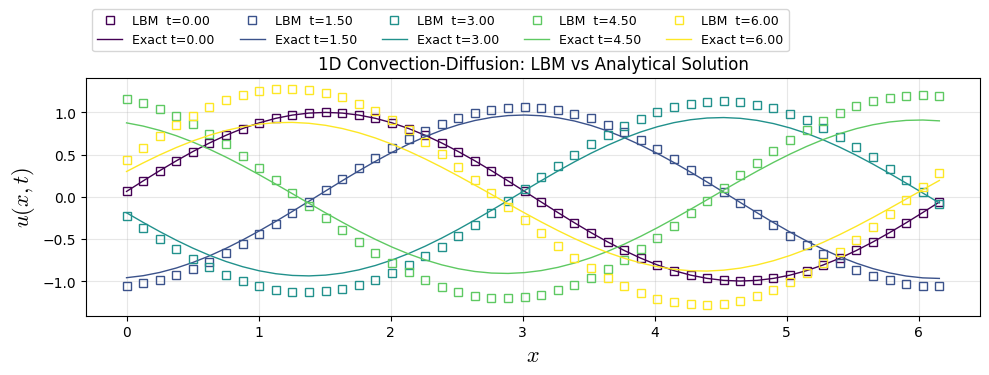

In [8]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# ---------------- parameters (physical units) ----------------
A   = 1.0  # Amplitude
phi = 0.0  # Wave initial shift
k_w   = 1.0  # Wave number
c   = 1.0  # wave speed
nu  = 0.0066666666666666666*np.pi # Diffusive coefficient
m_waves = 1 # Wave Period
L = m_waves * (2.0*np.pi / k_w) # Domain Lentgh
t_end = 6.0 # Final time
#-------------------Lattice-Properties-D1Q3-------------------------------
w = np.array([4.0/6.0, 1.0/6.0, 1.0/6.0],dtype="float64")
cx = np.array([0, 1, -1],dtype="int16")  
cs=1.0/np.sqrt(3.0);
# ---------------- parameters (numerical units) LBM-Scale----------------
Nx = 50 # Numerical Length
x  = np.linspace(0.0, L, Nx, endpoint=False,dtype="float64") # Numerical Domain
dx = L / Nx # Grid size
r=2**0 # dx/dt relation
dt = dx/r
ce = c/r
nue = nu * dt / (dx*dx)
tau = 0.5 + nue / cs**2
nt = int(np.ceil(t_end / dt))
print(f"dx={dx:.4e}, dt={dt:.4e}")
print(f"c_lbm={ce:.3f}, tau={tau:.4f}")
print(f"nt={nt:.3f}, nue={nue:.4f}")
#-------------------Initialization-Arrays-------------------------------
u=np.zeros((Nx),dtype="float64")
u = A * np.sin(k_w*(x+dx/2) + phi)
snaps=5 # number of states saved over time including 0 and t_end
u_snaps = np.empty(snaps, dtype=object) # array field used to same data over time
snaps_id = np.linspace(0, nt, snaps, dtype="int16") # timesteps to take the field
snap_index = {sid: i for i, sid in enumerate(snaps_id)}
for i in range(snaps):
    u_snaps[i] = np.zeros((Nx), dtype="float64")
f=np.zeros((3,Nx),dtype="float64")
# ----------------------------- Maind Loop ------------------------------
for k in range(0,3):
    f[k,:]=w[k]*(u[:]+cx[k]*ce*u[:]/cs**2)
for t in range(nt+1):
    #----------------------Macro------------------
    u[:]=f[0,:]+f[1,:]+f[2,:]
    #---------------------save-snaps--------------
    if t in snaps_id:
        i = snap_index[t]
        u_snaps[i][:]=u[:]
    #--------------------Collision----------------
    for k in range(0,3):
        f[k,:]= f[k,:] - (f[k,:] - w[k]*(u[:]+cx[k]*(ce*u[:])/cs**2))/tau
    #-----------------streaming-------------------
    for k in range(0,3):
        f[k,:]=np.roll(f[k,:], cx[k], axis=0)
#****************************************Data-Analysis*********************************************
# ---------------- exact solution ----------------
def u_exact(x, t, A, k_w, phi, c, nu):
    return A * np.exp(-nu * k_w**2 * t) * np.sin(k_w * ((x+dx/2) - c*t) + phi)
u_ana = np.empty(snaps, dtype=object) # array field used to same data over time
for i in range(snaps):
    u_ana[i] = np.zeros((Nx), dtype="float64")
# -----------------Plot Results --------------------
plt.figure(figsize=(10,4))
colors = plt.cm.viridis(np.linspace(0, 1, snaps))
for i in range(snaps):
    plt.plot(x, u_snaps[i], "s", color=colors[i], lw=1, label=f"LBM  t={(snaps_id[i]/nt)*t_end:.2f}",fillstyle='none')
    u_ana[i] = u_exact(x, (snaps_id[i]/nt)*t_end , A, k_w, phi, c, nu)
    plt.plot(x, u_ana[i], color=colors[i], lw=1, label=f"Exact t={(snaps_id[i]/nt)*t_end:.2f}")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

### FDM Solution (FTCS-SD) (LBM Framework $\tau=1$)

dx=1.2566e-01, dt=1.2566e-01
nt=48.000, r=1.0000
Property Conservation: sum(u(t=0))=-3.816e-15, sum(u(t=t_end))=-4.33e-15


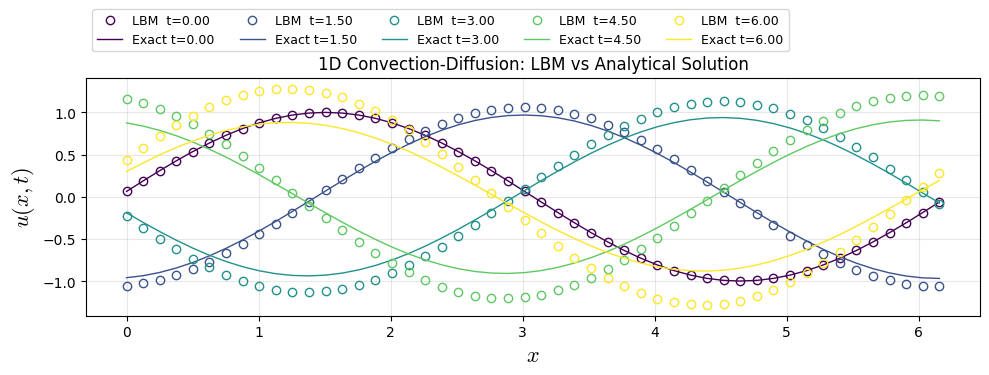

In [9]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# ---------------- parameters (physical units) ----------------
A   = 1.0  # Amplitude
phi = 0.0  # Wave initial shift
k_w   = 1.0  # Wave number
c   = 1.0  # wave speed
nu  = 0.0066666666666666666*np.pi # Diffusive coefficient
m_waves = 1 # Wave Period
L = m_waves * (2.0*np.pi / k_w) # Domain Lentgh
t_end = 6.0 # Final time
# ---------------- parameters (numerical units)----------------
Nx = 50 # Numerical Length
x  = np.linspace(0.0, L, Nx, endpoint=False,dtype="float64") # Numerical Domain
dx = L / Nx # Grid size
r=2**0 # dx/dt relation
dt = dx/r # time step
nt = int(np.ceil(t_end / dt))
print(f"dx={dx:.4e}, dt={dt:.4e}")
print(f"nt={nt:.3f}, r={r:.4f}")
# ---------------- Initialization ----------------
uf=np.zeros((Nx),dtype="float64")
uf = A * np.sin(k_w*(x+dx/2) + phi)
ufp=np.zeros((Nx),dtype="float64")
snaps=5 # number of states saved over time including 0 and t_end
uf_snaps = np.empty(snaps, dtype=object) # array field used to same data over time
snaps_id = np.linspace(0, nt, snaps, dtype="int16") # timesteps to take the field
snap_index = {sid: i for i, sid in enumerate(snaps_id)}
for i in range(snaps):
    uf_snaps[i] = np.zeros((Nx), dtype="float64")
# ----------------------------- Maind Loop ------------------------------
for t in range(nt+1):
    #---------------------save-snaps--------------
    if t in snaps_id:
        i = snap_index[t]
        uf_snaps[i][:]=uf[:]
    #---------------------------------------------
    ufp[:]=uf[:] + (dt/dx * c * (np.roll(uf[:], 1, axis=0) - np.roll(uf[:], -1, axis=0))/2.0  
                    + dt * nu * ( np.roll(uf[:], 1, axis=0) -2.0*uf[:] + np.roll(uf[:], -1, axis=0) ) / dx**2)
    uf[:]=ufp[:]
#****************************************Data-Analysis*********************************************
# ---------------- exact solution ----------------
def u_exact(x, t, A, k_w, phi, c, nu):
    return A * np.exp(-nu * k_w**2 * t) * np.sin(k_w * ((x+dx/2) - c*t) + phi)
u_ana = np.empty(snaps, dtype=object) # array field used to same data over time
for i in range(snaps):
    u_ana[i] = np.zeros((Nx), dtype="float64")
# -----------------Plot Results --------------------
print(f"Property Conservation: sum(u(t=0))={np.sum(uf_snaps[0]):.4g}, sum(u(t=t_end))={np.sum(uf_snaps[4]):.4g}")
plt.figure(figsize=(10,4))
colors = plt.cm.viridis(np.linspace(0, 1, snaps))
for i in range(snaps):
    plt.plot(x, uf_snaps[i], "o", color=colors[i], lw=1, label=f"LBM  t={(snaps_id[i]/nt)*t_end:.2f}",fillstyle='none')
    u_ana[i] = u_exact(x, (snaps_id[i]/nt)*t_end , A, k_w, phi, c, nu)
    plt.plot(x, u_ana[i], color=colors[i], lw=1, label=f"Exact t={(snaps_id[i]/nt)*t_end:.2f}")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

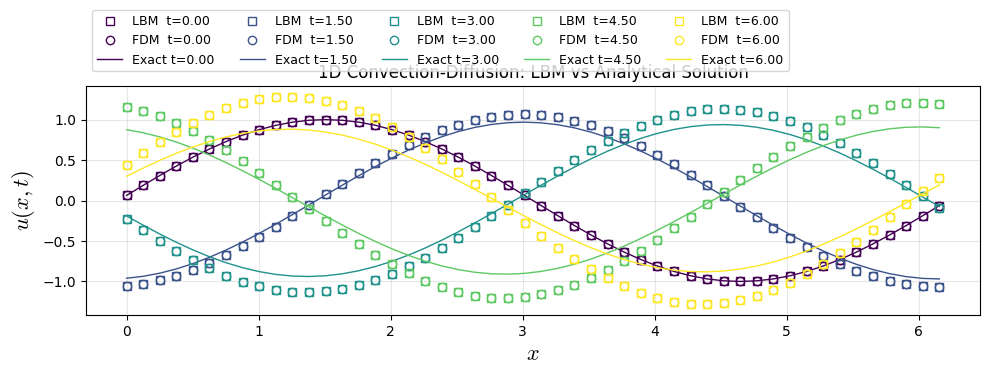

In [10]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# -----------------Plot Results --------------------
plt.figure(figsize=(10,4))
colors = plt.cm.viridis(np.linspace(0, 1, snaps))
for i in range(snaps):
    plt.plot(x, u_snaps[i], "s", color=colors[i], lw=1, label=f"LBM  t={(snaps_id[i]/nt)*t_end:.2f}",fillstyle='none')
    u_ana[i] = u_exact(x, (snaps_id[i]/nt)*t_end , A, k_w, phi, c, nu)
    plt.plot(x, uf_snaps[i], "o", color=colors[i], lw=1, label=f"FDM  t={(snaps_id[i]/nt)*t_end:.2f}",fillstyle='none')
    u_ana[i] = u_exact(x, (snaps_id[i]/nt)*t_end , A, k_w, phi, c, nu)
    plt.plot(x, u_ana[i], color=colors[i], lw=1, label=f"Exact t={(snaps_id[i]/nt)*t_end:.2f}")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

### FDM Solution (FTCS)

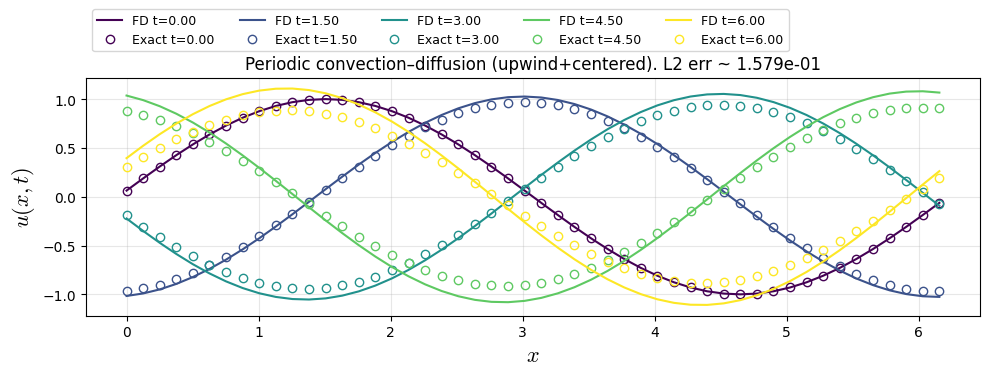

In [27]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# ---------------- parameters (physical units) ----------------
c  = 1.0      # convection speed
nu = 0.02     # diffusivity
A  = 1.0
phi = 0.0
L = 2*np.pi   # domain length
k = 1.0
t_end = 6.0
# ---------------- parameters (numerical units)----------------
Nx = 50
x = np.linspace(0.0, L, Nx, endpoint=False)  # IMPORTANT: periodic grid (no duplicate point at L)
dx = L / Nx
CFL = 0.6 # stable dt (explicit)
dt_adv = np.inf if abs(c) < 1e-15 else CFL * dx / abs(c)
dt_dif = np.inf if nu <= 0 else 0.45 * dx*dx / nu
dt = min(dt_adv, dt_dif)
Nt = int(np.ceil(t_end / dt))
dt = t_end / Nt
# print(f"dx={dx:.4g}, dt={dt:.4g}, Nt={Nt}, CFL={abs(c)*dt/dx:.3f}, diff={nu*dt/dx**2:.3f}")
# -------------------- initial condition --------------------
u = A * np.sin(k*(x+dx/2) + phi)
# snapshots
snap_times = np.linspace(0, t_end, 5)
snap_ids = set(np.round(snap_times / dt).astype(int))
snaps = []
# -------------------- Main Loop --------------------
for n in range(Nt + 1):
    t = n * dt
    #---------------------save-snaps--------------    
    if n in snap_ids:
        snaps.append((t, u.copy()))
    if n == Nt:
        break
    #----------------periodic shifts-----------------------------
    uL = np.roll(u, +1)  # u_{i-1}
    uR = np.roll(u, -1)  # u_{i+1}
    ux = (uR - uL) / (2*dx) # upwind for convection
    # centered for diffusion
    uxx = (uR - 2.0*u + uL) / (dx*dx)
    # explicit Euler update
    u = u - dt * c * ux + dt * nu * uxx
# -------------------- plot: numerical vs exact at same times --------------------
# print(f"Property Conservation: sum(u(t=0))={np.sum(snaps[0][1]):.4g}, sum(u(t=t_end))={np.sum(snaps[-1][1]):.4g}")
plt.figure(figsize=(10,4))
colors = plt.cm.viridis(np.linspace(0, 1, len(snaps)))
def u_exact(x, t, A, k, phi, c, nu):
    return A * np.exp(-nu * k**2 * t) * np.sin(k * ((x+dx/2) - c*t) + phi)
for i, (t, u_num) in enumerate(snaps):
    col = colors[i]
    u_ex = u_exact(x, t, A, k, phi, c, nu)
    plt.plot(x, u_num, color=col, label=f"FD t={t:.2f}")
    plt.plot(x, u_ex, "o", color=col, linewidth=2, label=f"Exact t={t:.2f}",fillstyle='none')

# error at final time
u_ex_final = u_exact(x, t_end, A, k, phi, c, nu)
err_l2 = np.sqrt(np.mean((u - u_ex_final)**2))
plt.title(f"Periodic convection–diffusion (upwind+centered). L2 err ~ {err_l2:.3e}")
plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()


### FDM Solution (FTFSCS)

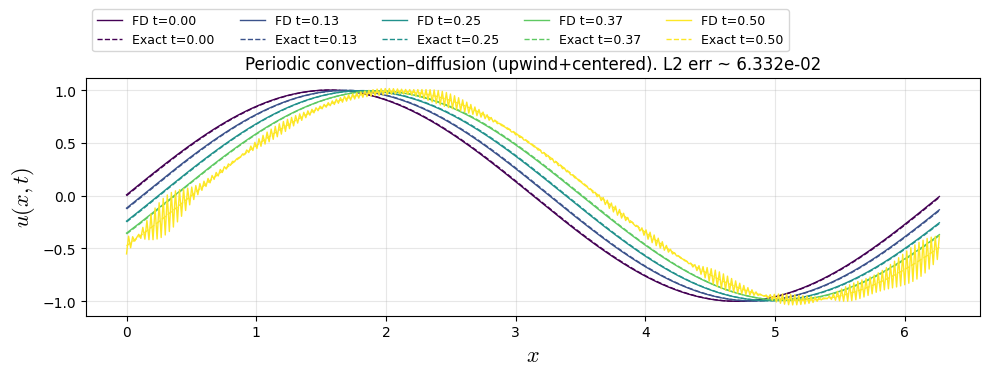

In [28]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# ---------------- parameters (physical units) ----------------
c  = 1.0      # convection speed
nu = 0.02     # diffusivity
A  = 1.0
phi = 0.0
L = 2*np.pi   # domain length
k = 1.0
t_end = 0.5
# ---------------- parameters (numerical units)----------------
Nx = 400
x = np.linspace(0.0, L, Nx, endpoint=False)  # IMPORTANT: periodic grid (no duplicate point at L)
dx = L / Nx
CFL = 0.6 # stable dt (explicit)
dt_adv = np.inf if abs(c) < 1e-15 else CFL * dx / abs(c)
dt_dif = np.inf if nu <= 0 else 0.45 * dx*dx / nu
dt = min(dt_adv, dt_dif)
Nt = int(np.ceil(t_end / dt))
dt = t_end / Nt
# print(f"dx={dx:.4g}, dt={dt:.4g}, Nt={Nt}, CFL={abs(c)*dt/dx:.3f}, diff={nu*dt/dx**2:.3f}")
# -------------------- initial condition --------------------
u = A * np.sin(k*(x+dx/2) + phi)
# snapshots
snap_times = np.linspace(0, t_end, 5)
snap_ids = set(np.round(snap_times / dt).astype(int))
snaps = []
# -------------------- Main Loop --------------------
for n in range(Nt + 1):
    t = n * dt
    #---------------------save-snaps--------------    
    if n in snap_ids:
        snaps.append((t, u.copy()))
    if n == Nt:
        break
    #----------------periodic shifts-----------------------------
    uL = np.roll(u, +1)  # u_{i-1}
    uR = np.roll(u, -1)  # u_{i+1}
    if c >= 0:
        ux = (u - uL) / dx # upwind for convection
    else:
        ux = (uR - u) / dx 
    # centered for diffusion
    uxx = (uR - 2.0*u + uL) / (dx*dx)
    # explicit Euler update
    u = u - dt * c * ux + dt * nu * uxx
# -------------------- plot: numerical vs exact at same times --------------------
plt.figure(figsize=(10,4))
colors = plt.cm.viridis(np.linspace(0, 1, len(snaps)))
def u_exact(x, t, A, k, phi, c, nu):
    return A * np.exp(-nu * k**2 * t) * np.sin(k * (x - c*t) + phi)
for i, (t, u_num) in enumerate(snaps):
    col = colors[i]
    u_ex = u_exact(x, t, A, k, phi, c, nu)
    plt.plot(x, u_num, color=col, linewidth=1, label=f"FD t={t:.2f}")
    plt.plot(x, u_ex, "--", color=col, linewidth=1, label=f"Exact t={t:.2f}")

# error at final time
u_ex_final = u_exact(x, t_end, A, k, phi, c, nu)
err_l2 = np.sqrt(np.mean((u - u_ex_final)**2))
plt.title(f"Periodic convection–diffusion (upwind+centered). L2 err ~ {err_l2:.3e}")
plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()


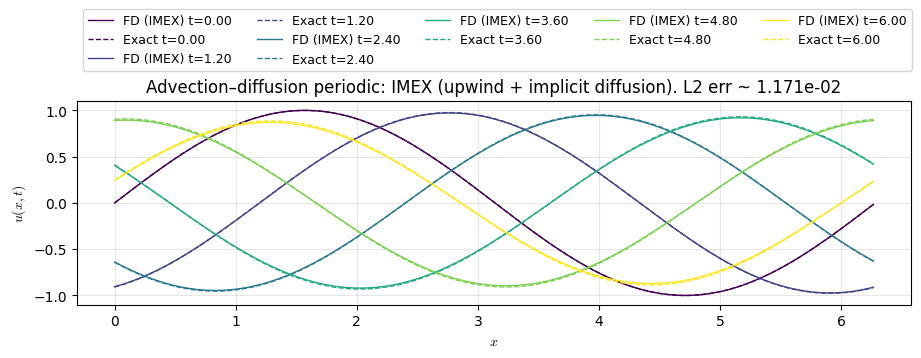

In [29]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# ---------------------------------------------------------------------
def u_exact(x, t, A, k, phi, c, nu):
    return A * np.exp(-nu * k**2 * t) * np.sin(k * (x - c*t) + phi)

def solve_periodic_imex(c=1.0, nu=0.02, A=1.0, k=1.0, phi=0.0,
                        L=2*np.pi, Nx=400, t_end=1.0, CFL=0.6,
                        n_snaps=5, diag_every=50):
    """
    IMEX scheme:
      - Advection: explicit upwind
      - Diffusion: implicit backward Euler (periodic via FFT)
    This is very robust. Diffusion has no stability restriction.
    """

    # periodic grid (no duplicate endpoint)
    x = np.linspace(0.0, L, Nx, endpoint=False)
    dx = L / Nx

    # choose dt from advection CFL only
    if abs(c) < 1e-15:
        dt = t_end / 2000.0
    else:
        dt = CFL * dx / abs(c)

    Nt = int(np.ceil(t_end / dt))
    dt = t_end / Nt

    CFL_num = 0.0 if abs(c) < 1e-15 else abs(c) * dt / dx
    # print(f"Nx={Nx}, L={L:.6g}, dx={dx:.6g}")
    # print(f"Nt={Nt}, dt={dt:.6g}, CFL=|c|dt/dx={CFL_num:.3f}")
    # print(f"nu={nu:.6g} (diffusion is implicit -> no dt restriction)")

    # initial condition
    u = u_exact(x, 0.0, A, k, phi, c, nu).astype(np.float64)

    # snapshot schedule
    snap_times = np.linspace(0, t_end, n_snaps)
    snap_ids = set(np.round(snap_times / dt).astype(int).tolist())
    snaps = []

    # FFT wave numbers for periodic diffusion solve
    # For FFT in numpy, frequencies are cycles per unit; convert to angular: 2π * freq
    kk = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)
    # diffusion implicit factor in Fourier space: u_hat^{n+1} = u_hat^* / (1 + nu*dt*kk^2)
    diff_denom = 1.0 + nu * dt * (kk**2)

    for n in range(Nt + 1):
        t = n * dt

        if n in snap_ids:
            snaps.append((t, u.copy()))

        # diagnostics
        if (diag_every is not None) and (n % diag_every == 0 or n == Nt):
            if not np.isfinite(u).all():
                bad = np.where(~np.isfinite(u))[0][:10]
                raise FloatingPointError(f"NaN/Inf detected at step {n}, indices {bad}")
            # print(f"step {n:6d}/{Nt}: t={t:.4f}, min={u.min():+.3e}, max={u.max():+.3e}")

        if n == Nt:
            break

        # ---- explicit upwind advection ----
        uL = np.roll(u, +1)  # u_{i-1}
        uR = np.roll(u, -1)  # u_{i+1}

        if c >= 0:
            ux = (u - uL) / dx
        else:
            ux = (uR - u) / dx

        u_star = u - dt * c * ux  # after advection

        # ---- implicit diffusion via FFT ----
        uhat = np.fft.fft(u_star)
        uhat_new = uhat / diff_denom
        u = np.real(np.fft.ifft(uhat_new))

    return x, snaps, u

# -------------------- run + plot --------------------
if __name__ == "__main__":
    c  = 1.0
    nu = 0.02
    A  = 1.0
    k  = 1.0
    phi = 0.0
    L = 2*np.pi
    Nx = 400
    t_end = 6.0

    x, snaps, u_final = solve_periodic_imex(
        c=c, nu=nu, A=A, k=k, phi=phi, L=L, Nx=Nx, t_end=t_end,
        CFL=0.6, n_snaps=6, diag_every=100)

    # plot numerical vs exact at same times
    plt.figure(figsize=(10,4))
    colors = plt.cm.viridis(np.linspace(0, 1, len(snaps)))
    for i, (t, u_num) in enumerate(snaps):
        col = colors[i]
        u_ex = u_exact(x, t, A, k, phi, c, nu)
        plt.plot(x, u_num, color=col, linewidth=1, label=f"FD (IMEX) t={t:.2f}")
        plt.plot(x, u_ex, "--", color=col, linewidth=1, label=f"Exact t={t:.2f}")

    u_ex_final = u_exact(x, t_end, A, k, phi, c, nu)
    err_l2 = np.sqrt(np.mean((u_final - u_ex_final)**2))
    plt.title(f"Advection–diffusion periodic: IMEX (upwind + implicit diffusion). L2 err ~ {err_l2:.3e}")
    plt.xlabel("$x$")
    plt.ylabel("$u(x,t)$")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.3))
    plt.tight_layout()

## 2nd Benchmark: 1D Perturbation wave-decay

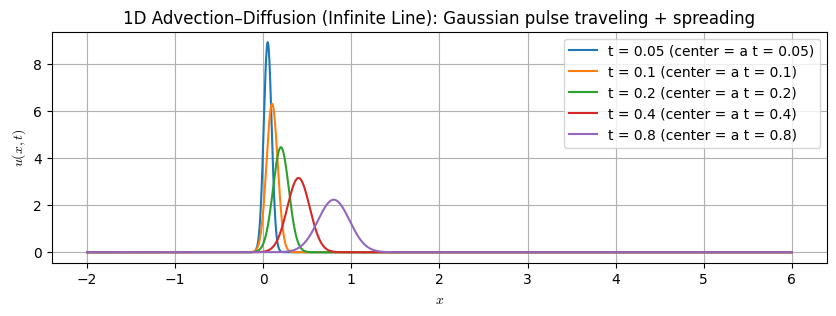

In [18]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
def u_gaussian_advdiff(x, t, a=1.0, nu=0.02):
    """
    Fundamental solution of 1D advection-diffusion on R:
        u_t + a u_x = nu u_xx
    with initial condition u(x,0) = delta(x).
    """
    t = np.asarray(t, dtype=float)
    if np.any(t <= 0):
        raise ValueError("All t must be > 0 for the fundamental (Gaussian) solution.")
    return (1.0 / np.sqrt(4.0 * np.pi * nu * t)) * np.exp(-((x - a * t) ** 2) / (4.0 * nu * t))

# ----------------- parameters -----------------
a = 1.0       # advection speed
nu = 0.02     # diffusivity

# Spatial domain for plotting (infinite line approximated by a large interval)
x = np.linspace(-2.0, 6.0, 2000)

# Times to plot (must be > 0)
times = [0.05, 0.10, 0.20, 0.40, 0.80]

# ----------------- plot -----------------
plt.figure(figsize=(10,3))
for t in times:
    u = u_gaussian_advdiff(x, t, a=a, nu=nu)
    plt.plot(x, u, label=f"t = {t:g} (center = a t = {a*t:g})")

plt.xlabel("$x$")
plt.ylabel("$u(x,t)$")
plt.title("1D Advection–Diffusion (Infinite Line): Gaussian pulse traveling + spreading")
plt.legend()
plt.grid(True)
plt.show()


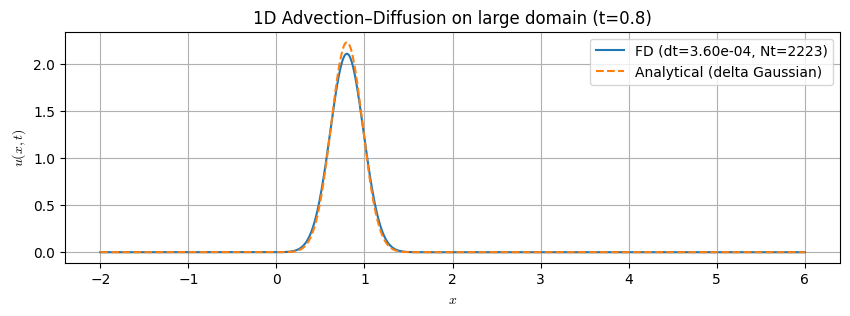

In [19]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# -----------------------------
# Analytical solution (delta IC)
# -----------------------------
def u_analytic_gaussian(x, t, a, nu):
    if t <= 0:
        # not defined for t=0 in classical sense (delta); handle separately if needed
        return np.zeros_like(x)
    return (1.0 / np.sqrt(4.0 * np.pi * nu * t)) * np.exp(-((x - a * t) ** 2) / (4.0 * nu * t))


# -----------------------------
# Finite-difference solver
# -----------------------------
def solve_advdiff_fd(a=1.0, nu=0.02, x_min=-2.0, x_max=6.0, Nx=2001, t_end=0.8, cfl=0.5, rdiff=0.45, x0=0.0, sigma0=0.03,):
    """
    Solve u_t + a u_x = nu u_xx on a large interval [x_min, x_max]
    using:
      - upwind for advection
      - centered difference for diffusion
      - forward Euler in time

    "Whole line" is approximated by large domain + far-field BC u=0 at both ends.

    IC: a narrow Gaussian (approx delta)
        u(x,0) = 1/(sqrt(2*pi)*sigma0) * exp(-(x-x0)^2/(2*sigma0^2))
    (mass ~ 1)
    """
    # grid
    x = np.linspace(x_min, x_max, Nx)
    dx = x[1] - x[0]

    # time step from both constraints:
    # advection CFL: |a| dt/dx <= cfl
    # diffusion: nu dt/dx^2 <= rdiff  (explicit stability)
    dt_adv = np.inf if a == 0 else cfl * dx / abs(a)
    dt_dif = np.inf if nu == 0 else rdiff * dx * dx / nu
    dt = min(dt_adv, dt_dif)

    Nt = int(np.ceil(t_end / dt))
    dt = t_end / Nt  # adjust so we land exactly at t_end

    # initial condition: narrow Gaussian with unit mass
    u = (1.0 / (np.sqrt(2.0 * np.pi) * sigma0)) * np.exp(-0.5 * ((x - x0) / sigma0) ** 2)

    # precompute coefficients
    # diffusion number
    mu = nu * dt / (dx * dx)

    # time-march
    for n in range(Nt):
        # enforce far-field Dirichlet BCs ~ "goes to 0 at infinity"
        u[0] = 0.0
        u[-1] = 0.0

        # copy for update
        un = u.copy()

        # -----------------
        # Advection (upwind)
        # -----------------
        if a >= 0:
            # u_x ≈ (u_i - u_{i-1})/dx
            adv = a * (un[1:-1] - un[0:-2]) / dx
        else:
            # u_x ≈ (u_{i+1} - u_i)/dx
            adv = a * (un[2:] - un[1:-1]) / dx

        # -----------------
        # Diffusion (centered)
        # -----------------
        dif = nu * (un[2:] - 2.0 * un[1:-1] + un[0:-2]) / (dx * dx)

        # Forward Euler update
        u[1:-1] = un[1:-1] - dt * adv + dt * dif

    return x, u, dt, Nt
# -----------------------------
# Run + plot comparison
# -----------------------------
if __name__ == "__main__":
    a = 1.0
    nu = 0.02
    t_end = 0.8

    # FD solve
    x, u_num, dt, Nt = solve_advdiff_fd(
        a=a, nu=nu,
        x_min=-2.0, x_max=6.0, Nx=2001,
        t_end=t_end,
        cfl=0.5, rdiff=0.45,
        x0=0.0, sigma0=0.03,   # narrow Gaussian ~ delta
    )

    # Analytic (delta) at t_end
    u_exact = u_analytic_gaussian(x, t_end, a, nu)

    # Plot
    plt.figure(figsize=(10,3))
    plt.plot(x, u_num, label=f"FD (dt={dt:.2e}, Nt={Nt})")
    plt.plot(x, u_exact, "--", label="Analytical (delta Gaussian)")
    plt.xlabel("$x$")
    plt.ylabel("$u(x,t)$")
    plt.title(f"1D Advection–Diffusion on large domain (t={t_end})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Optional: check mass (should be ~1 if boundaries far enough)
    mass = np.trapz(u_num, x)

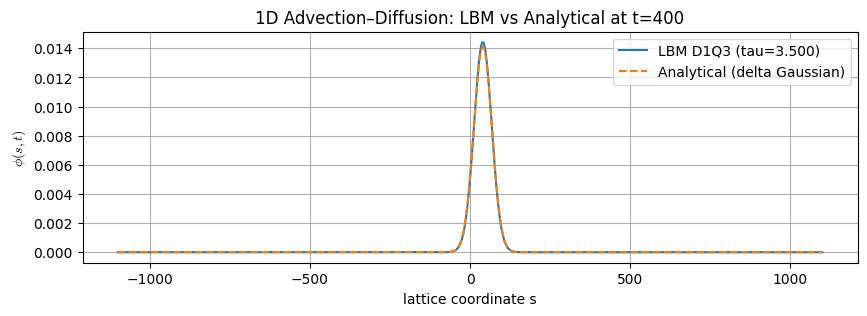

In [20]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
def analytic_delta_solution(x, t, a, nu):
    """Fundamental solution on R: delta IC -> moving Gaussian."""
    t = float(t)
    if t <= 0:
        return np.zeros_like(x)
    return (1.0 / np.sqrt(4.0 * np.pi * nu * t)) * np.exp(-((x - a * t) ** 2) / (4.0 * nu * t))

def lbm_advdiff_1d_d1q3(
    Nx=2000,
    x_min=-200.0,
    x_max=200.0,
    a=0.10,          # advection speed in lattice units (dx=dt=1)
    nu=1.0,          # diffusion in lattice units
    t_end=400.0,     # total time in lattice timesteps
    sigma0=2.0,      # initial Gaussian width (lattice units)
    x0=0.0,          # initial center (physical x)
    bc_value=0.0     # far-field Dirichlet ~ 0 at ends
):
    """
    D1Q3 BGK LBM for passive scalar advection-diffusion with constant velocity a.
    Domain is a large finite interval approximating the whole line.

    Uses non-periodic streaming (manual shift) + Dirichlet far-field BCs on f.
    """

    # Grid
    x = np.linspace(x_min, x_max, Nx)
    dx = x[1] - x[0]

    # Lattice units assumption: we want dx=1, dt=1 ideally.
    # Here x is "physical-like" for plotting; internally we treat lattice index spacing as 1.
    # So just interpret a, nu, sigma0, t_end in *lattice units*.
    # (If you want physical mapping, set x = np.arange(Nx) and then scale externally.)

    # D1Q3 model
    c = np.array([0, 1, -1], dtype=int)
    w = np.array([2/3, 1/6, 1/6], dtype=float)
    cs2 = 1.0 / 3.0

    # Relaxation time from diffusion
    tau = nu / cs2 + 0.5  # tau = 3*nu + 0.5
    omega = 1.0 / tau

    if abs(a) >= 1.0:
        raise ValueError("For D1Q3 with dx=dt=1, keep |a| < 1 (preferably much smaller).")
    if tau <= 0.5:
        raise ValueError("Need tau > 0.5 (i.e., nu > 0).")

    # Initial condition: narrow Gaussian with unit mass (approx delta)
    # In lattice units, mass ~ sum(phi) * dx_lattice; here dx_lattice=1.
    # We'll build phi on the index grid for correctness.
    xi = np.arange(Nx, dtype=float)
    # Map x0 (physical) to index approximately:
    # If you want exact lattice alignment, set x = np.arange(Nx) and choose x0 in index units.
    # Here we map by linear interpolation:
    x0_idx = (x0 - x_min) / (x_max - x_min) * (Nx - 1)

    phi0 = (1.0 / (np.sqrt(2.0 * np.pi) * sigma0)) * np.exp(-0.5 * ((xi - x0_idx) / sigma0) ** 2)

    # Distributions f_i
    # Equilibrium for scalar advection-diffusion (linear in velocity):
    # f_i^eq = w_i * phi * (1 + (c_i * a)/cs2)
    f = np.zeros((3, Nx), dtype=float)
    for i in range(3):
        f[i, :] = w[i] * phi0 * (1.0 + (c[i] * a) / cs2)

    # Time stepping
    nsteps = int(round(t_end))
    for _ in range(nsteps):
        # macroscopic scalar
        phi = f.sum(axis=0)

        # collision
        feq = np.zeros_like(f)
        for i in range(3):
            feq[i, :] = w[i] * phi * (1.0 + (c[i] * a) / cs2)
        f = (1.0 - omega) * f + omega * feq

        # streaming (non-periodic)
        f_stream = np.zeros_like(f)

        # c=0 stays
        f_stream[0, :] = f[0, :]

        # c=+1 shifts right: f1(x+1) = f1(x)  -> new[j] = old[j-1]
        f_stream[1, 1:] = f[1, :-1]
        f_stream[1, 0]  = 0.0  # will set BC below

        # c=-1 shifts left: f2(x-1) = f2(x) -> new[j] = old[j+1]
        f_stream[2, :-1] = f[2, 1:]
        f_stream[2, -1]  = 0.0  # will set BC below

        f = f_stream

        # Far-field Dirichlet BC for phi ~ bc_value:
        # simplest: overwrite distributions at boundaries with equilibrium of bc_value.
        # Left boundary j=0
        phiL = bc_value
        f[:, 0] = np.array([
            w[0] * phiL * (1.0 + (c[0] * a) / cs2),
            w[1] * phiL * (1.0 + (c[1] * a) / cs2),
            w[2] * phiL * (1.0 + (c[2] * a) / cs2),
        ])

        # Right boundary j=Nx-1
        phiR = bc_value
        f[:, -1] = np.array([
            w[0] * phiR * (1.0 + (c[0] * a) / cs2),
            w[1] * phiR * (1.0 + (c[1] * a) / cs2),
            w[2] * phiR * (1.0 + (c[2] * a) / cs2),
        ])

    phi_num = f.sum(axis=0)
    return x, phi_num, tau

if __name__ == "__main__":
    # Pick parameters that are safe and visually clear
    a  = 0.10   # lattice advection speed
    nu = 1.00   # lattice diffusion
    t_end = 400 # steps

    x, phi_num, tau = lbm_advdiff_1d_d1q3(Nx=2200, x_min=-200.0, x_max=200.0, a=a, nu=nu, t_end=t_end, sigma0=2.0, x0=0.0, bc_value=0.0)

    # Analytic solution comparison:
    # IMPORTANT: The analytic "delta IC" solution matches best if the initial condition is a delta.
    # Here we used a narrow Gaussian (approx delta), so comparison is still good after some time.
    # Also note: in this script, x is for plotting; the true lattice coordinate is index i.
    # For a consistent analytic comparison, use lattice coordinate s = (i - i0).
    Nx = len(x)
    i = np.arange(Nx, dtype=float)
    i0 = (0.0 - (-200.0)) / (200.0 - (-200.0)) * (Nx - 1)  # same mapping used above
    s = i - i0  # lattice coordinate centered at 0

    phi_exact = analytic_delta_solution(s, t_end, a, nu)

    plt.figure(figsize=(10,3))
    plt.plot(s, phi_num, label=f"LBM D1Q3 (tau={tau:.3f})")
    plt.plot(s, phi_exact, "--", label="Analytical (delta Gaussian)")
    plt.xlabel("lattice coordinate s")
    plt.ylabel(r"$\phi(s,t)$")
    plt.title(f"1D Advection–Diffusion: LBM vs Analytical at t={t_end}")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Mass check (should be ~1 if boundaries are far and bc_value=0):
    mass = np.sum(phi_num)  # dx_lattice=1